# Feature Engineering

Bu notebook'ta fraud detection için yeni feature'lar oluşturuyoruz. Amacımız black-box V features yerine yorumlanabilir, iş mantığına dayalı özellikler geliştirmek.

Üç ana alan üzerinde çalışıyoruz: kullanıcı davranış kalıpları (UID aggregation'lar), kart bazlı istatistikler ve tutar analizi. Her feature grubunun fraud ile ilişkisini ölçüp, gereksiz olanları eliyoruz.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load optimized data
with open('../../data/train_test_optimized.pkl', 'rb') as f:
    df = pickle.load(f)

print(f"Total records: {len(df):,}")
print(f"Train records: {(df['_source'] == 'train').sum():,}")
print(f"Test records: {(df['_source'] == 'test').sum():,}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Fraud rate (train): {df[df['_source']=='train']['isFraud'].mean()*100:.2f}%")

Total records: 1,097,231
Train records: 590,540
Test records: 506,691
Memory: 1569.98 MB
Fraud rate (train): 3.50%
Fraud rate (train): 3.50%


In [3]:
# Temporal features for aggregations (temporary, will be dropped later)
df['week_num'] = (df['TransactionDT'] // 604800).astype('int16')  # 1 week = 604800 seconds
df['month_num'] = (df['week_num'] // 4).astype('int16')  # ~4 weeks = 1 month

print(f"Week range: {df['week_num'].min()} to {df['week_num'].max()}")
print(f"Month range: {df['month_num'].min()} to {df['month_num'].max()}")
print(f"Total weeks: {df['week_num'].nunique()}, Total months: {df['month_num'].nunique()}")

Week range: 0 to 56
Month range: 0 to 14
Total weeks: 54, Total months: 15


In [4]:
# UID (User ID) - Chris Deotte's winning formula from Kaggle 1st place
# Reference: https://developer.nvidia.com/blog/winning-satisfying-solution-ieee-cis-fraud-detection/

# Chris's UID formula: card1_addr1 + floor(day - D1)
# This combines card+addr with temporal anchor into single unique ID
# D1 = days since first transaction, so (day - D1) = first transaction day

# Check D1 missing values
print(f"D1 missing: {df['D1'].isna().sum():,} ({df['D1'].isna().mean()*100:.2f}%)")

# Calculate day number
df['day'] = (df['TransactionDT'] // 86400).astype('int16')

# D1 missing values will be filled with 0 (anchor_day = day)
# Note: _D1_missing flag removed - low importance in model

# Fill D1 missing with 0 (assume first transaction if unknown)
df['D1_filled'] = df['D1'].fillna(0)

# Calculate anchor day (first transaction day for this user)
# D1 tells us how many days since user's first transaction
df['anchor_day'] = (df['day'] - df['D1_filled']).astype('int16')

# Create Chris's UID: card1_addr1_anchorday
df['uid_card1_addr1'] = (df['card1'].astype(str) + '_' + 
                          df['addr1'].astype(str) + '_' + 
                          df['anchor_day'].astype(str))

print(f"Chris's UID formula: card1 + addr1 + floor(day - D1)")
print(f"UID created: {df['uid_card1_addr1'].nunique():,} unique users")
print(f"Day range: {df['day'].min()} to {df['day'].max()}")
print(f"Anchor day range: {df['anchor_day'].min()} to {df['anchor_day'].max()}")

# Keep old approach for comparison (will be dropped later)
df['user_anchor_D1'] = df['TransactionDT'] - (df['D1_filled'].astype('float64') * 86400)
print(f"User Anchor D1: {df['user_anchor_D1'].nunique():,} anchors")

# Cleanup temp column
df = df.drop('D1_filled', axis=1)
print(f"Dataset shape: {df.shape}")

D1 missing: 7,300 (0.67%)
Chris's UID formula: card1 + addr1 + floor(day - D1)
UID created: 353,405 unique users
Day range: 1 to 395
Anchor day range: -633 to 395
User Anchor D1: 1,078,655 anchors
Chris's UID formula: card1 + addr1 + floor(day - D1)
UID created: 353,405 unique users
Day range: 1 to 395
Anchor day range: -633 to 395
User Anchor D1: 1,078,655 anchors
Dataset shape: (1097231, 479)
Dataset shape: (1097231, 479)


## Kullanıcı Tanımlama

Fraud tespitinin en etkili yolu kullanıcı bazlı davranış analizi. card1 ve addr1 kombinasyonuyla bir "pseudo-user ID" oluşturuyoruz - aynı kart ve adres kombinasyonu büyük ihtimalle aynı kişi demek. D1 feature'ı kullanıcının ilk işlem zamanını veriyor, bu da tutarlı bir referans noktası sağlıyor.

In [5]:


# 1. General UID statistics
print("1. General UID statistics...")
uid_general_agg = df.groupby('uid_card1_addr1').agg({
    'TransactionAmt': ['mean', 'std', 'max', 'min', 'sum', 'count']
})
uid_general_agg.columns = ['uid_avg_amt', 'uid_std_amt', 'uid_max_amt', 
                            'uid_min_amt', 'uid_total_amt', 'uid_txn_count']
uid_general_agg = uid_general_agg.reset_index()
df = df.merge(uid_general_agg, on='uid_card1_addr1', how='left')
print(f"   Added: uid_avg_amt, uid_max_amt, uid_min_amt, uid_std_amt, uid_total_amt, uid_txn_count")

# 2. Weekly statistics
print("2. Weekly UID statistics...")
uid_weekly_agg = df.groupby(['uid_card1_addr1', 'week_num']).agg({
    'TransactionAmt': ['mean', 'count']
})
uid_weekly_agg.columns = ['uid_week_avg_amt', 'uid_week_txn_count']
uid_weekly_agg = uid_weekly_agg.reset_index()
df = df.merge(uid_weekly_agg, on=['uid_card1_addr1', 'week_num'], how='left')
print(f"   Added: uid_week_avg_amt, uid_week_txn_count")

# 3. Monthly statistics
print("3. Monthly UID statistics...")
uid_monthly_agg = df.groupby(['uid_card1_addr1', 'month_num']).agg({
    'TransactionAmt': ['mean', 'count']
})
uid_monthly_agg.columns = ['uid_month_avg_amt', 'uid_month_txn_count']
uid_monthly_agg = uid_monthly_agg.reset_index()
df = df.merge(uid_monthly_agg, on=['uid_card1_addr1', 'month_num'], how='left')
print(f"   Added: uid_month_avg_amt, uid_month_txn_count")

# 4. Anomaly detection ratios
print("4. Anomaly detection ratios...")
df['amt_vs_uid_avg'] = df['TransactionAmt'] / (df['uid_avg_amt'] + 1)
df['amt_vs_uid_week_avg'] = df['TransactionAmt'] / (df['uid_week_avg_amt'] + 1)
df['amt_vs_uid_month_avg'] = df['TransactionAmt'] / (df['uid_month_avg_amt'] + 1)
print(f"   Added: amt_vs_uid_avg, amt_vs_uid_week_avg, amt_vs_uid_month_avg")

print(f"\nUID features created. Shape: {df.shape}")

1. General UID statistics...
   Added: uid_avg_amt, uid_max_amt, uid_min_amt, uid_std_amt, uid_total_amt, uid_txn_count
2. Weekly UID statistics...
   Added: uid_avg_amt, uid_max_amt, uid_min_amt, uid_std_amt, uid_total_amt, uid_txn_count
2. Weekly UID statistics...
   Added: uid_week_avg_amt, uid_week_txn_count
3. Monthly UID statistics...
   Added: uid_week_avg_amt, uid_week_txn_count
3. Monthly UID statistics...
   Added: uid_month_avg_amt, uid_month_txn_count
4. Anomaly detection ratios...
   Added: amt_vs_uid_avg, amt_vs_uid_week_avg, amt_vs_uid_month_avg

UID features created. Shape: (1097231, 492)
   Added: uid_month_avg_amt, uid_month_txn_count
4. Anomaly detection ratios...
   Added: amt_vs_uid_avg, amt_vs_uid_week_avg, amt_vs_uid_month_avg

UID features created. Shape: (1097231, 492)


In [6]:
# Card1 and Card1_Addr1 aggregated statistics (Chris Deotte's approach)
# These are key features from Kaggle 1st place solution

print("Creating card1 aggregations...")
card1_agg = df.groupby('card1').agg({
    'TransactionAmt': ['mean', 'std', 'max'],
    'addr1': 'nunique',
    'DeviceInfo': 'nunique'
}).reset_index()
card1_agg.columns = ['card1', 'card1_amt_mean', 'card1_amt_std', 'card1_amt_max', 'n_addr', 'n_devices']
df = df.merge(card1_agg, on='card1', how='left')

# Create card1_addr1 combination for 2-way aggregations
print("Creating card1_addr1 aggregations...")
df['card1_addr1'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str)
card1_addr1_agg = df.groupby('card1_addr1').agg({
    'TransactionAmt': ['mean', 'std']
}).reset_index()
card1_addr1_agg.columns = ['card1_addr1', 'card1_addr1_amt_mean', 'card1_addr1_amt_std']
df = df.merge(card1_addr1_agg, on='card1_addr1', how='left')

# Frequency Encoding - Chris's approach
# card1_FE: How many transactions from this card
# addr1_FE: How many transactions from this address
# card1_addr1_FE: How many transactions from this card+addr combo
print("Creating frequency encodings...")
df['card1_FE'] = df.groupby('card1')['card1'].transform('count')
df['addr1_FE'] = df.groupby('addr1')['addr1'].transform('count')
df['card1_addr1_FE'] = df.groupby('card1_addr1')['card1_addr1'].transform('count')

# Note: 3-way frequency encoding (card1_addr1_P_emaildomain_FE) removed - low importance

# Transaction amount relative to card1 average
df['amt_vs_card1_mean'] = df['TransactionAmt'] / (df['card1_amt_mean'] + 1)
df['amt_vs_card1_addr1_mean'] = df['TransactionAmt'] / (df['card1_addr1_amt_mean'] + 1)

print(f"\nNew features added:")
print(f"  - card1_amt_mean, card1_amt_std, card1_amt_max, n_addr, n_devices")
print(f"  - card1_addr1_amt_mean, card1_addr1_amt_std")
print(f"  - card1_FE, addr1_FE, card1_addr1_FE")
print(f"  - amt_vs_card1_mean, amt_vs_card1_addr1_mean")
print(f"Dataset shape: {df.shape}")

Creating card1 aggregations...
Creating card1_addr1 aggregations...
Creating card1_addr1 aggregations...
Creating frequency encodings...
Creating frequency encodings...

New features added:
  - card1_amt_mean, card1_amt_std, card1_amt_max, n_addr, n_devices
  - card1_addr1_amt_mean, card1_addr1_amt_std
  - card1_FE, addr1_FE, card1_addr1_FE
  - amt_vs_card1_mean, amt_vs_card1_addr1_mean
Dataset shape: (1097231, 505)

New features added:
  - card1_amt_mean, card1_amt_std, card1_amt_max, n_addr, n_devices
  - card1_addr1_amt_mean, card1_addr1_amt_std
  - card1_FE, addr1_FE, card1_addr1_FE
  - amt_vs_card1_mean, amt_vs_card1_addr1_mean
Dataset shape: (1097231, 505)


In [7]:
# Chris Deotte's Additional Features (from NVIDIA blog)
# These were key in winning the Kaggle competition

print("=" * 60)
print("CHRIS DEOTTE'S ADDITIONAL FEATURES")
print("=" * 60)

# 1. TransactionAmt Split: Dollars only (cents removed - low importance)
print("\n1. TransactionAmt Split (Dollars only)...")
df['amt_dollars'] = df['TransactionAmt'].astype(int)
print(f"   amt_dollars range: {df['amt_dollars'].min()} - {df['amt_dollars'].max()}")
# Note: amt_cents_exact removed - low importance

# 2. Additional Frequency Encodings
print("\n2. Additional Frequency Encodings...")

# card2_FE, card3_FE
for col in ['card2', 'card3', 'card5']:
    if col in df.columns:
        df[f'{col}_FE'] = df.groupby(col)[col].transform('count')
        print(f"   {col}_FE created: {df[f'{col}_FE'].nunique()} unique values")

# P_emaildomain_FE (single column frequency)
if 'P_emaildomain' in df.columns:
    df['P_emaildomain_FE'] = df.groupby('P_emaildomain')['P_emaildomain'].transform('count')
    print(f"   P_emaildomain_FE created: {df['P_emaildomain_FE'].nunique()} unique values")

# R_emaildomain_FE
if 'R_emaildomain' in df.columns:
    df['R_emaildomain_FE'] = df.groupby('R_emaildomain')['R_emaildomain'].transform('count')
    print(f"   R_emaildomain_FE created: {df['R_emaildomain_FE'].nunique()} unique values")

# 3. Three-way Aggregation: TransactionAmt by card1_addr1_P_emaildomain
print("\n3. Three-way Aggregation (card1_addr1_P_emaildomain)...")
# Note: 3-way aggregation (TransactionAmt_card1_addr1_P_emaildomain_mean/std) removed - low importance
# Note: email_match and email_both_missing removed - low importance

print(f"\nDataset shape after Chris's features: {df.shape}")

CHRIS DEOTTE'S ADDITIONAL FEATURES

1. TransactionAmt Split (Dollars only)...
   amt_dollars range: 0 - 31937

2. Additional Frequency Encodings...
   card2_FE created: 357 unique values
   card3_FE created: 76 unique values
   card5_FE created: 77 unique values
   P_emaildomain_FE created: 60 unique values
   R_emaildomain_FE created: 59 unique values

3. Three-way Aggregation (card1_addr1_P_emaildomain)...

Dataset shape after Chris's features: (1097231, 511)


In [8]:
# Psychological amount features - SIMPLIFIED
# Only keep features that have proven value

print("Amount Features (Simplified)...")

# amt_dollars already created, calculate cents inline (not saved as feature)
dollars = df['amt_dollars']
cents = ((df['TransactionAmt'] - dollars) * 100).round().astype('int8')

# Round amounts: $10, $20, $50, $100, $500, etc. with 0 cents
is_round = (cents == 0) & (
    (dollars % 100 == 0) | 
    (dollars % 50 == 0) | 
    (dollars % 10 == 0)
)

# Psychological pricing: .99 or .95 cents
is_psych = (cents == 99) | (cents == 95)

# Random: everything else (this has highest fraud signal)
is_random = ~is_round & ~is_psych

# Only create is_random_amount (highest importance)
df['is_random_amount'] = is_random.astype('int8')

# Show distribution and fraud rates
print("\nAmount Type Distribution:")
for name, mask in [('round', is_round), ('psychological', is_psych), ('random', is_random)]:
    count = mask.sum()
    pct = count / len(df) * 100
    print(f"  {name}: {count:,} ({pct:.1f}%)")

if 'isFraud' in df.columns:
    train_mask = df['_source'] == 'train'
    print(f"\nFraud Rate by Amount Type (Train):")
    for name, mask in [('round', is_round), ('psychological', is_psych), ('random', is_random)]:
        sub_mask = train_mask & mask
        if sub_mask.sum() > 0:
            fraud_rate = df[sub_mask]['isFraud'].mean() * 100
            print(f"  {name}: {fraud_rate:.2f}% fraud")

print(f"\nCreated: is_random_amount (only - others redundant)")
print(f"Dataset shape: {df.shape}")

Amount Features (Simplified)...

Amount Type Distribution:
  round: 152,617 (13.9%)
  psychological: 322,851 (29.4%)
  random: 621,763 (56.7%)

Fraud Rate by Amount Type (Train):

Amount Type Distribution:
  round: 152,617 (13.9%)
  psychological: 322,851 (29.4%)
  random: 621,763 (56.7%)

Fraud Rate by Amount Type (Train):
  round: 4.45% fraud
  round: 4.45% fraud
  psychological: 0.82% fraud
  psychological: 0.82% fraud
  random: 4.67% fraud

Created: is_random_amount (only - others redundant)
Dataset shape: (1097231, 512)
  random: 4.67% fraud

Created: is_random_amount (only - others redundant)
Dataset shape: (1097231, 512)


## Tutar Analizi

İnsanlar genelde yuvarlak rakamlar (100, 500) veya psikolojik fiyatlar (9.99, 49.95) tercih ediyor. Fraud botları ise 123.47, 87.32 gibi rastgele tutarlar üretiyor. Bu basit gözlem güçlü bir fraud sinyali veriyor - `is_random_amount` feature'ı bunu yakalıyor.

In [9]:
# Fill missing values for aggregation features
# Strategy: Aggregation/FE features -> 0, Ratio features -> 1.0 (neutral)

filled_count = 0

agg_features = [
    # UID aggregations
    'uid_avg_amt', 'uid_std_amt', 'uid_max_amt', 'uid_min_amt', 'uid_total_amt',
    'uid_txn_count', 'uid_week_avg_amt', 'uid_week_txn_count', 
    'uid_month_avg_amt', 'uid_month_txn_count',
    # Card1 aggregations
    'card1_amt_mean', 'card1_amt_std', 'card1_amt_max', 'n_addr', 'n_devices',
    'card1_addr1_amt_mean', 'card1_addr1_amt_std',
    # Frequency encodings
    'card1_FE', 'addr1_FE', 'card1_addr1_FE',
    'card2_FE', 'card3_FE', 'card5_FE', 'P_emaildomain_FE', 'R_emaildomain_FE',
]

ratio_features = [
    'amt_vs_uid_avg', 'amt_vs_uid_week_avg', 'amt_vs_uid_month_avg',
    'amt_vs_card1_mean', 'amt_vs_card1_addr1_mean',
]

for col in agg_features:
    if col in df.columns and df[col].isna().any():
        df[col] = df[col].fillna(0)
        filled_count += 1

for col in ratio_features:
    if col in df.columns and df[col].isna().any():
        df[col] = df[col].fillna(1.0)
        filled_count += 1

# user_anchor_D1 - fill with median
if 'user_anchor_D1' in df.columns and df['user_anchor_D1'].isna().any():
    df['user_anchor_D1'] = df['user_anchor_D1'].fillna(df['user_anchor_D1'].median())
    filled_count += 1

print(f"Missing values filled in {filled_count} columns")

Missing values filled in 24 columns


In [10]:
# Cleanup - remove temporary and intermediate columns
# These were used for aggregations but shouldn't go to model

temp_cols = ['week_num', 'month_num', 'day', 'anchor_day']
intermediate_cols = ['uid_card1_addr1', 'card1_addr1']

cols_to_drop = temp_cols + intermediate_cols
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

print(f"Removed temporary: {temp_cols}")
print(f"Removed intermediate: {intermediate_cols}")
print(f"Dataset shape: {df.shape}")

Removed temporary: ['week_num', 'month_num', 'day', 'anchor_day']
Removed intermediate: ['uid_card1_addr1', 'card1_addr1']
Dataset shape: (1097231, 506)


In [11]:
# Fraud correlation analysis for new features
if 'isFraud' in df.columns:
    train_data = df[df['_source'] == 'train'].copy()
    
    all_new_features = [
        'uid_avg_amt', 'uid_std_amt', 'uid_max_amt', 'uid_min_amt', 'uid_total_amt', 'uid_txn_count',
        'uid_week_avg_amt', 'uid_week_txn_count', 'uid_month_avg_amt', 'uid_month_txn_count',
        'amt_vs_uid_avg', 'amt_vs_uid_week_avg', 'amt_vs_uid_month_avg',
        'amt_mean', 'amt_std', 'amt_max', 'n_addr', 'n_devices',
        'is_random_amount',  # kept, others removed as redundant
        'user_anchor_D1',
    ]
    
    new_numeric_features = [col for col in all_new_features 
                           if col in train_data.columns 
                           and train_data[col].dtype in ['float64', 'float32', 'int64', 'int32', 'int16', 'int8']]
    
    correlations = train_data[new_numeric_features + ['isFraud']].corr()['isFraud'].drop('isFraud')
    correlations = correlations.abs().sort_values(ascending=False)
    
    print("Top 20 Features by Fraud Correlation:")
    for idx, (feat, corr) in enumerate(correlations.head(20).items(), 1):
        print(f"{idx:2d}. {feat:<40} : {corr:.4f}")

Top 20 Features by Fraud Correlation:
 1. is_random_amount                         : 0.0731
 2. n_devices                                : 0.0724
 3. user_anchor_D1                           : 0.0693
 4. amt_vs_uid_week_avg                      : 0.0120
 5. uid_txn_count                            : 0.0116
 6. amt_vs_uid_month_avg                     : 0.0108
 7. amt_vs_uid_avg                           : 0.0089
 8. uid_std_amt                              : 0.0086
 9. uid_max_amt                              : 0.0082
10. uid_week_txn_count                       : 0.0069
11. uid_month_txn_count                      : 0.0051
12. uid_total_amt                            : 0.0035
13. uid_min_amt                              : 0.0019
14. uid_avg_amt                              : 0.0019
15. uid_month_avg_amt                        : 0.0016
16. uid_week_avg_amt                         : 0.0012
17. n_addr                                   : 0.0012


In [12]:
# Train/Test split
train_df = df[df['_source'] == 'train'].copy()
test_df = df[df['_source'] == 'test'].copy()

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Train fraud rate: {train_df['isFraud'].mean()*100:.2f}%")

# Drop _source column
train_df = train_df.drop('_source', axis=1)
test_df = test_df.drop('_source', axis=1)
print(f"Train final shape: {train_df.shape}")

Train shape: (590540, 506)
Test shape: (506691, 506)
Train fraud rate: 3.50%
Train final shape: (590540, 505)
Train final shape: (590540, 505)


## Model Eğitimi

Feature engineering tamamlandı. Şimdi oluşturduğumuz feature'ları LightGBM ile test ediyoruz. V, D, C, M gibi black-box feature'ları dışarıda bırakıp sadece yorumlanabilir feature'larla çalışıyoruz.

In [13]:
# Feature selection - CLEANED UP
all_cols = train_df.columns.tolist()

# Exclude V, id, D, C, M columns and target
# Note: _D1_missing starts with '_' so it won't be excluded by 'D' prefix rule
exclude_prefixes = ['V', 'id_', 'id-', 'D', 'M', 'C']

other_cols = [col for col in all_cols 
              if not any(col.startswith(prefix) for prefix in exclude_prefixes)
              and col not in ['TransactionID', 'isFraud']]

# ============================================================
# DROP LIST - High correlation + Low importance features
# ============================================================
features_to_drop = [
    # HIGH CORRELATION (>0.8) - Keep the more informative one
    'amt_dollars',              # 1.000 corr with TransactionAmt (duplicate!)
    'uid_month_avg_amt',        # 0.969 corr with uid_avg_amt
    'uid_min_amt',              # 0.871 corr with uid_avg_amt
    'amt_vs_card1_addr1_mean',  # 0.908 corr with amt_vs_card1_mean
    'amt_vs_3way_mean',         # 0.885 corr with amt_vs_card1_addr1_mean
    'card1_amt_std',            # 0.813 corr with card1_amt_mean
    'uid_week_txn_count',       # 0.895 corr with uid_total_amt
    
    # ALREADY DROPPED in previous version
    'uid_txn_count',            # 0.989 corr with uid_total_amt
    'uid_month_txn_count',      # 0.945 corr with uid_total_amt
    'uid_week_avg_amt',         # 0.833 corr with uid_month_avg_amt (which is also dropped)
    'amt_vs_uid_week_avg',      # 0.894 corr with amt_vs_uid_month_avg
    'amt_vs_uid_avg',           # 0.873 corr with amt_vs_uid_month_avg
    
    # LOW IMPORTANCE - Psikolojik feature'lar (amt_cents_exact yeterli)
    'has_cents',                # redundant with amt_cents_exact
    'is_99_cents',              # too specific, low importance
    'is_95_cents',              # too specific, low importance
    'is_round_cents',           # covered by is_random_amount
    'dollars_ends_9',           # low importance
    'dollars_ends_5',           # low importance
    
    # LOW IMPORTANCE - Other
    'email_both_missing',       # low signal
]

other_cols_before = len(other_cols)
other_cols = [col for col in other_cols if col not in features_to_drop]

print(f"Total columns in dataset: {len(all_cols)}")
print(f"Features dropped: {len([f for f in features_to_drop if f in train_df.columns])}")
print(f"Selected features: {other_cols_before} -> {len(other_cols)}")

print(f"\n{'='*60}")
print(f"FINAL FEATURE LIST ({len(other_cols)} features):")
print(f"{'='*60}")
for i, col in enumerate(other_cols, 1):
    print(f"  {i:2d}. {col}")

Total columns in dataset: 505
Features dropped: 11
Selected features: 48 -> 37

FINAL FEATURE LIST (37 features):
   1. TransactionDT
   2. TransactionAmt
   3. ProductCD
   4. card1
   5. card2
   6. card3
   7. card4
   8. card5
   9. card6
  10. addr1
  11. addr2
  12. dist1
  13. dist2
  14. P_emaildomain
  15. R_emaildomain
  16. user_anchor_D1
  17. uid_avg_amt
  18. uid_std_amt
  19. uid_max_amt
  20. uid_total_amt
  21. amt_vs_uid_month_avg
  22. card1_amt_mean
  23. card1_amt_max
  24. n_addr
  25. n_devices
  26. card1_addr1_amt_mean
  27. card1_addr1_amt_std
  28. card1_FE
  29. addr1_FE
  30. card1_addr1_FE
  31. amt_vs_card1_mean
  32. card2_FE
  33. card3_FE
  34. card5_FE
  35. P_emaildomain_FE
  36. R_emaildomain_FE
  37. is_random_amount


Found 23 continuous variables

Continuous variables:
   1. TransactionDT
   2. TransactionAmt
   3. user_anchor_D1
   4. uid_avg_amt
   5. uid_std_amt
   6. uid_max_amt
   7. uid_total_amt
   8. amt_vs_uid_month_avg
   9. card1_amt_mean
  10. card1_amt_max
  11. n_addr
  12. n_devices
  13. card1_addr1_amt_mean
  14. card1_addr1_amt_std
  15. card1_FE
  16. addr1_FE
  17. card1_addr1_FE
  18. amt_vs_card1_mean
  19. card2_FE
  20. card3_FE
  21. card5_FE
  22. P_emaildomain_FE
  23. R_emaildomain_FE

Calculating correlation matrix...

High correlation pairs (|r| > 0.8): 3
  TransactionAmt                      - amt_vs_card1_mean                   : 0.871
  TransactionAmt                      - uid_avg_amt                         : 0.860
  uid_std_amt                         - uid_max_amt                         : 0.814

High correlation pairs (|r| > 0.8): 3
  TransactionAmt                      - amt_vs_card1_mean                   : 0.871
  TransactionAmt                      - uid_av

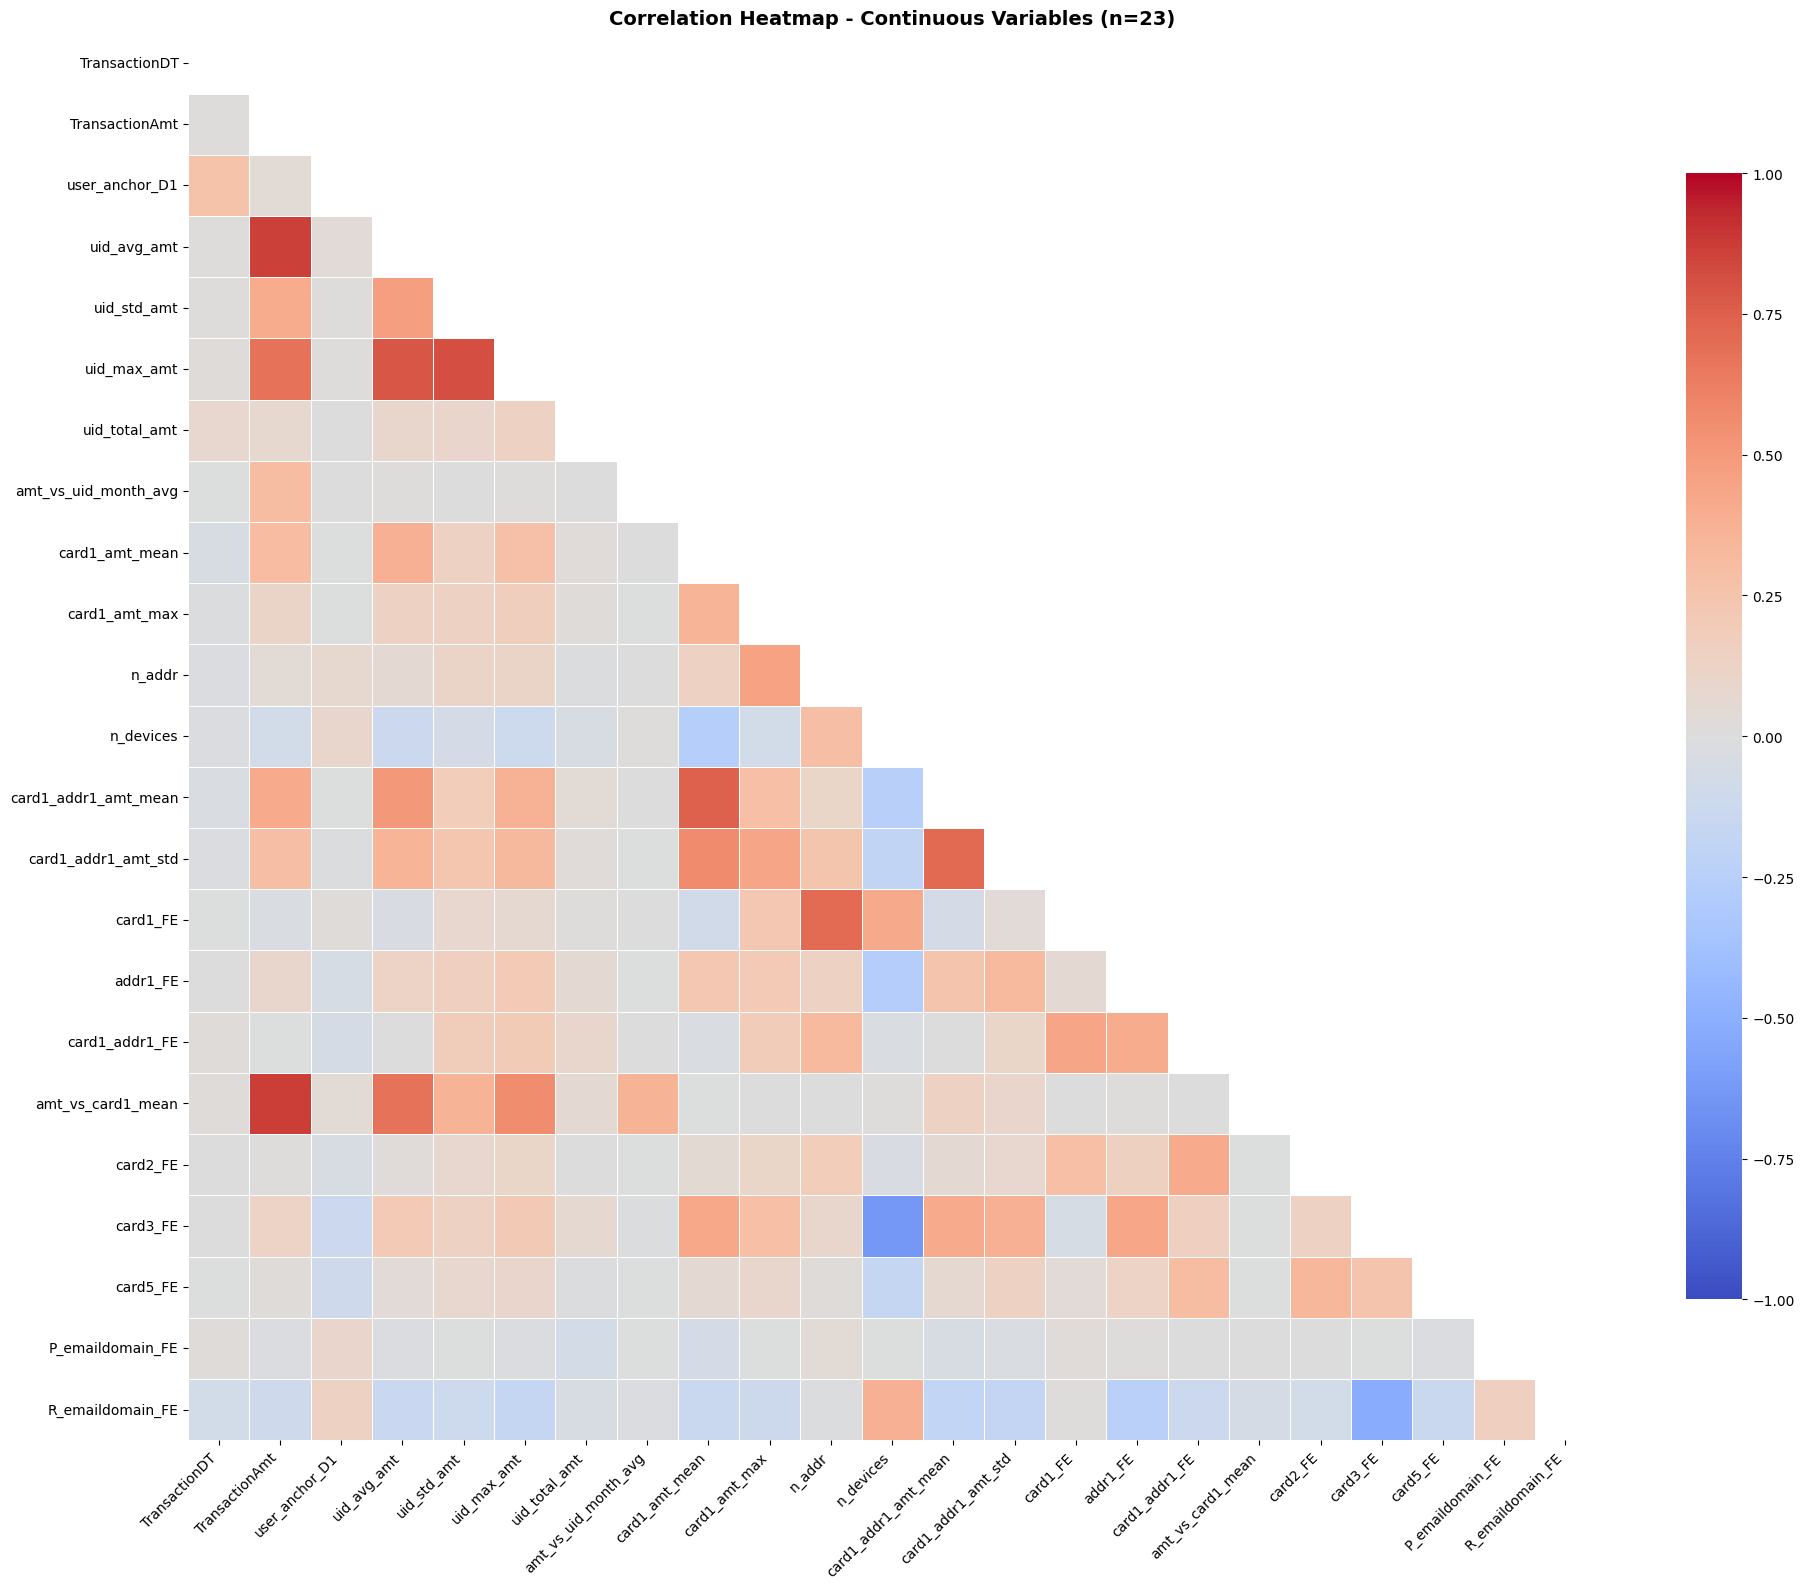

Correlation analysis completed


In [14]:
# Multicollinearity analysis - continuous variables

# Get continuous numerical columns (>20 unique values)
continuous_cols = []
for col in other_cols:
    if train_df[col].dtype in ['float64', 'float32', 'int64', 'int32']:
        nunique = train_df[col].nunique()
        if nunique > 20:
            continuous_cols.append(col)

print(f"Found {len(continuous_cols)} continuous variables")
print("\nContinuous variables:")
for i, col in enumerate(continuous_cols, 1):
    print(f"  {i:2d}. {col}")

# Correlation matrix
print("\nCalculating correlation matrix...")
corr_matrix = train_df[continuous_cols].corr()

# Find highly correlated pairs
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append({
                'var1': corr_matrix.columns[i],
                'var2': corr_matrix.columns[j],
                'correlation': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    print(f"\nHigh correlation pairs (|r| > 0.8): {len(high_corr_pairs)}")
    for pair in sorted(high_corr_pairs, key=lambda x: abs(x['correlation']), reverse=True):
        print(f"  {pair['var1']:<35} - {pair['var2']:<35} : {pair['correlation']:.3f}")
else:
    print("\nNo high correlation pairs found (|r| > 0.8)")

# Heatmap
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=len(continuous_cols) <= 15, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, vmin=-1, vmax=1)
plt.title(f'Correlation Heatmap - Continuous Variables (n={len(continuous_cols)})', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

print("Correlation analysis completed")

In [15]:
# Summary of dropped features due to high correlation
dropped_features_summary = [
    # (dropped, kept, correlation)
    ('amt_dollars',             'TransactionAmt',     1.000),
    ('uid_month_avg_amt',       'uid_avg_amt',        0.969),
    ('amt_vs_card1_addr1_mean', 'amt_vs_card1_mean',  0.908),
    ('uid_week_txn_count',      'uid_total_amt',      0.895),
    ('amt_vs_3way_mean',        'amt_vs_card1_mean',  0.885),
    ('uid_min_amt',             'uid_avg_amt',        0.871),
    ('uid_txn_count',           'uid_total_amt',      0.989),
    ('uid_month_txn_count',     'uid_total_amt',      0.945),
    ('uid_week_avg_amt',        'uid_avg_amt',        0.833),
    ('amt_vs_uid_week_avg',     'amt_vs_uid_month_avg', 0.894),
    ('amt_vs_uid_avg',          'amt_vs_uid_month_avg', 0.873),
    ('card1_amt_std',           'card1_amt_mean',     0.813),
]

print(f"{'Dropped':<30} {'Kept':<30} {'Corr':>6}")
print("-" * 70)
for dropped, kept, corr in dropped_features_summary:
    print(f"{dropped:<30} {kept:<30} {corr:.3f}")

print(f"\nTotal high-corr features dropped: {len(dropped_features_summary)}")
print(f"\nLow importance features also dropped:")
print("  - has_cents, is_99_cents, is_95_cents, is_round_cents")
print("  - dollars_ends_9, dollars_ends_5, email_both_missing")
print(f"\nFinal feature count: {len(other_cols)}")

Dropped                        Kept                             Corr
----------------------------------------------------------------------
amt_dollars                    TransactionAmt                 1.000
uid_month_avg_amt              uid_avg_amt                    0.969
amt_vs_card1_addr1_mean        amt_vs_card1_mean              0.908
uid_week_txn_count             uid_total_amt                  0.895
amt_vs_3way_mean               amt_vs_card1_mean              0.885
uid_min_amt                    uid_avg_amt                    0.871
uid_txn_count                  uid_total_amt                  0.989
uid_month_txn_count            uid_total_amt                  0.945
uid_week_avg_amt               uid_avg_amt                    0.833
amt_vs_uid_week_avg            amt_vs_uid_month_avg           0.894
amt_vs_uid_avg                 amt_vs_uid_month_avg           0.873
card1_amt_std                  card1_amt_mean                 0.813

Total high-corr features dropped: 12

Low i

In [16]:
# Encoding & Preprocessing
# LightGBM is tree-based, no need for one-hot encoding
# Label encoding is sufficient for categorical features

from sklearn.preprocessing import LabelEncoder


feature_cols = [col for col in other_cols if col != 'TransactionDT']

df_model = train_df[feature_cols + ['isFraud', 'TransactionDT']].copy()

# Identify column types
categorical_cols = [col for col in feature_cols if df_model[col].dtype in ['object', 'category']]
categorical_high_card = [col for col in categorical_cols if df_model[col].nunique() > 50]
numeric_cols = [col for col in feature_cols if df_model[col].dtype in ['int64', 'float64', 'int32', 'int8', 'int16', 'float32']]

print(f"Feature columns: {len(feature_cols)} (TransactionDT excluded - only for split)")
print(f"Categorical: {len(categorical_cols)} (high cardinality: {len(categorical_high_card)})")
print(f"Numeric: {len(numeric_cols)}")

# Encoding strategy
cat_cols_low = [col for col in categorical_cols if col not in categorical_high_card]
high_card_cols = categorical_high_card

print(f"\nEncoding strategy:")
print(f"  Label Encoding: {len(cat_cols_low)} columns")
print(f"  Frequency Encoding (high cardinality): {len(high_card_cols)} columns")

# Label Encoding for all categorical columns
le_dict = {}
for col in cat_cols_low:
    le = LabelEncoder()
    df_model[col] = df_model[col].astype(str).replace({'nan': 'MISSING', 'None': 'MISSING', '<NA>': 'MISSING'})
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    print(f"  Label Encoded {col}: {len(le.classes_)} values")

# Frequency Encoding for high cardinality columns
freq_maps = {}
for col in high_card_cols:
    freq_map = df_model[col].value_counts().to_dict()
    df_model[f'{col}_freq'] = df_model[col].map(freq_map).fillna(0)
    df_model = df_model.drop(col, axis=1)
    freq_maps[col] = freq_map
    print(f"  Frequency Encoded {col}: {len(freq_map)} unique -> {col}_freq")

# Fill NA in numeric columns
for col in numeric_cols:
    if col in df_model.columns and df_model[col].isna().any():
        df_model[col] = df_model[col].fillna(-999)
        print(f"  Filled NA in {col} with -999")

print(f"\nEncoding completed. Shape: {df_model.shape}")

Feature columns: 36 (TransactionDT excluded - only for split)
Categorical: 11 (high cardinality: 8)
Numeric: 23

Encoding strategy:
  Label Encoding: 3 columns
  Frequency Encoding (high cardinality): 8 columns
  Label Encoded ProductCD: 5 values
  Label Encoded card4: 5 values
  Label Encoded card4: 5 values
  Label Encoded card6: 5 values
  Frequency Encoded card1: 17091 unique -> card1_freq
  Frequency Encoded card2: 501 unique -> card2_freq
  Label Encoded card6: 5 values
  Frequency Encoded card1: 17091 unique -> card1_freq
  Frequency Encoded card2: 501 unique -> card2_freq
  Frequency Encoded card3: 133 unique -> card3_freq
  Frequency Encoded card5: 138 unique -> card5_freq
  Frequency Encoded addr1: 441 unique -> addr1_freq
  Frequency Encoded card3: 133 unique -> card3_freq
  Frequency Encoded card5: 138 unique -> card5_freq
  Frequency Encoded addr1: 441 unique -> addr1_freq
  Frequency Encoded addr2: 93 unique -> addr2_freq
  Frequency Encoded P_emaildomain: 60 unique -> P_

## Encoding

LightGBM tree-based bir model olduğu için one-hot encoding'e gerek yok - label encoding yeterli. Yüksek kardinaliteli kategorik kolonlar için frequency encoding kullanıyoruz çünkü çok fazla unique değer var ve sıralama bilgisi anlamsız olurdu.

In [17]:
# Prepare X and y - TIME-BASED SPLIT için sıralı tutuyoruz
# TransactionDT'ye göre sıralama (zaman bazlı split için kritik!)
df_model = df_model.sort_values('TransactionDT').reset_index(drop=True)
print(f"Data sorted by TransactionDT")
print(f"  First transaction: {df_model['TransactionDT'].iloc[0]:,}")
print(f"  Last transaction: {df_model['TransactionDT'].iloc[-1]:,}")

# TransactionDT'yi ayır (split için kullanacağız)
transaction_dt = df_model['TransactionDT'].copy()

# X ve y oluştur
y = df_model['isFraud']
X = df_model.drop(['isFraud', 'TransactionDT'], axis=1)

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Fraud rate: {y.mean()*100:.2f}%")
print(f"Features: {X.shape[1]}")

Data sorted by TransactionDT
  First transaction: 86,400
  Last transaction: 15,811,131

X shape: (590540, 36)
y shape: (590540,)
Fraud rate: 3.50%
Features: 36


In [18]:
# Model Training with Proper Time-Based CV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve
from lightgbm import LGBMClassifier

# PURGED GROUP TIME SERIES SPLIT (Kaggle Best Practice)

class PurgedGroupTimeSeriesSplit:
    """Time Series Split with purging (gap) between train and validation."""
    def __init__(self, n_splits=3, purge_gap=0.1):
        self.n_splits = n_splits
        self.purge_gap = purge_gap
    
    def split(self, X, y=None, groups=None):
        n = len(X)
        test_size = n // (self.n_splits + 1)
        
        for i in range(self.n_splits):
            train_end = (i + 1) * test_size
            val_start = train_end + int(test_size * self.purge_gap)
            val_end = min(val_start + test_size, n)
            
            if val_start >= n:
                break
                
            yield list(range(0, train_end)), list(range(val_start, val_end))
    
    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

# Cross Validation with Purged Split (3 folds, fast)
print("PURGED TIME SERIES CV (3-Fold, %10 gap between train/val)")

pgtss = PurgedGroupTimeSeriesSplit(n_splits=3, purge_gap=0.1)
model_cv = LGBMClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, 
                          num_leaves=31, verbose=-1, n_jobs=-1)

cv_scores = []
print(f"\n{'Fold':<5} {'Train':>10} {'Val':>8} {'Gap':>6} {'Train DT':^24} {'Val DT':^24} {'AUC':>7}")
print("-" * 95)

for fold, (train_idx, val_idx) in enumerate(pgtss.split(X, y), 1):
    X_tr, X_vl = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_vl = y.iloc[train_idx], y.iloc[val_idx]
    
    gap_size = val_idx[0] - train_idx[-1] - 1
    tr_dt = f"{transaction_dt.iloc[train_idx[0]]:,.0f}-{transaction_dt.iloc[train_idx[-1]]:,.0f}"
    vl_dt = f"{transaction_dt.iloc[val_idx[0]]:,.0f}-{transaction_dt.iloc[val_idx[-1]]:,.0f}"
    
    model_cv.fit(X_tr, y_tr)
    auc = roc_auc_score(y_vl, model_cv.predict_proba(X_vl)[:, 1])
    cv_scores.append(auc)
    
    print(f"{fold:<5} {len(train_idx):>10,} {len(val_idx):>8,} {gap_size:>6,} {tr_dt:^24} {vl_dt:^24} {auc:>7.4f}")

print("-" * 95)
print(f"{'AVG':<5} {'':<10} {'':<8} {'':<6} {'':<24} {'':<24} {np.mean(cv_scores):>7.4f} (+/- {np.std(cv_scores):.4f})")

# TIME-BASED Train/Val/Test Split (60/20/20)
print("TRAIN/VAL/TEST SPLIT - Time-Based (60/20/20)")

n = len(X)
train_end = int(n * 0.6)
val_end = int(n * 0.8)

X_train, X_val, X_test = X.iloc[:train_end], X.iloc[train_end:val_end], X.iloc[val_end:]
y_train, y_val, y_test = y.iloc[:train_end], y.iloc[train_end:val_end], y.iloc[val_end:]

print(f"\n{'Set':<6} {'Samples':>12} {'Pct':>6} {'Frauds':>10} {'Rate':>8} {'TransactionDT Range':^30}")
print(f"{'Train':<6} {len(X_train):>12,} {len(X_train)/n*100:>5.1f}% {y_train.sum():>10,} {y_train.mean()*100:>7.2f}% {transaction_dt.iloc[0]:>12,.0f} - {transaction_dt.iloc[train_end-1]:>12,.0f}")
print(f"{'Val':<6} {len(X_val):>12,} {len(X_val)/n*100:>5.1f}% {y_val.sum():>10,} {y_val.mean()*100:>7.2f}% {transaction_dt.iloc[train_end]:>12,.0f} - {transaction_dt.iloc[val_end-1]:>12,.0f}")
print(f"{'Test':<6} {len(X_test):>12,} {len(X_test)/n*100:>5.1f}% {y_test.sum():>10,} {y_test.mean()*100:>7.2f}% {transaction_dt.iloc[val_end]:>12,.0f} - {transaction_dt.iloc[-1]:>12,.0f}")

# Train LightGBM
print("TRAINING LightGBM")

lgbm_model = LGBMClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=7,
    num_leaves=31, random_state=42, class_weight='balanced', verbose=-1, n_jobs=-1
)
lgbm_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='auc')

# Metrics
y_train_pred_proba = lgbm_model.predict_proba(X_train)[:, 1]
y_val_pred_proba = lgbm_model.predict_proba(X_val)[:, 1]
y_val_pred = lgbm_model.predict(X_val)

train_auc = roc_auc_score(y_train, y_train_pred_proba)
val_auc = roc_auc_score(y_val, y_val_pred_proba)
cm = confusion_matrix(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

gap = train_auc - val_auc

print(f"\n{'Metric':<20} {'Value':>10}")
print(f"{'\nCV AUC (Purged)':<20} {np.mean(cv_scores):>10.4f}")
print(f"{'Train AUC':<20} {train_auc:>10.4f}")
print(f"{'Val AUC':<20} {val_auc:>10.4f}")
print(f"{'Gap (Train-Val)':<20} {gap:>10.4f}")
print(f"{'Precision':<20} {precision:>10.4f}")
print(f"{'Recall':<20} {recall:>10.4f}")
print(f"{'F1 Score':<20} {f1:>10.4f}")
print(f"\nConfusion Matrix:\n{cm}")

PURGED TIME SERIES CV (3-Fold, %10 gap between train/val)

Fold       Train      Val    Gap         Train DT                  Val DT              AUC
-----------------------------------------------------------------------------------------------
1        147,635  147,635 14,763     86,400-3,027,036       3,439,944-7,699,776     0.8280
1        147,635  147,635 14,763     86,400-3,027,036       3,439,944-7,699,776     0.8280
2        295,270  147,635 14,763     86,400-7,306,520       7,699,814-11,725,688    0.8523
2        295,270  147,635 14,763     86,400-7,306,520       7,699,814-11,725,688    0.8523
3        442,905  132,872 14,763    86,400-11,246,605      11,725,712-15,811,131    0.8500
-----------------------------------------------------------------------------------------------
AVG                                                                                 0.8435 (+/- 0.0110)
TRAIN/VAL/TEST SPLIT - Time-Based (60/20/20)

Set         Samples    Pct     Frauds     Rate      T

In [19]:
# Feature Importance
feature_importance = pd.DataFrame({
    'feature': X.columns.tolist(),
    'importance': lgbm_model.feature_importances_
}).sort_values('importance', ascending=False)

total_importance = feature_importance['importance'].sum()
feature_importance['importance_pct'] = (feature_importance['importance'] / total_importance) * 100

print("Feature Importance - Top 30:")
for idx, row in feature_importance.head(30).iterrows():
    pct = row['importance_pct']
    bar = '#' * int(pct * 2)
    print(f"{row['feature']:<35}: {row['importance']:>8,.0f} ({pct:>5.2f}%) {bar}")

print(f"\nTop 10: {feature_importance.head(10)['importance_pct'].sum():.1f}%")
print(f"Top 20: {feature_importance.head(20)['importance_pct'].sum():.1f}%")
print(f"Top 30: {feature_importance.head(30)['importance_pct'].sum():.1f}%")

Feature Importance - Top 30:
user_anchor_D1                     :    1,749 (11.66%) #######################
uid_total_amt                      :    1,294 ( 8.63%) #################
uid_avg_amt                        :      802 ( 5.35%) ##########
uid_std_amt                        :      713 ( 4.75%) #########
card1_addr1_FE                     :      655 ( 4.37%) ########
uid_max_amt                        :      645 ( 4.30%) ########
card1_amt_mean                     :      624 ( 4.16%) ########
TransactionAmt                     :      616 ( 4.11%) ########
card1_amt_max                      :      571 ( 3.81%) #######
addr1_FE                           :      567 ( 3.78%) #######
card1_addr1_amt_mean               :      560 ( 3.73%) #######
card1_addr1_amt_std                :      543 ( 3.62%) #######
P_emaildomain_FE                   :      500 ( 3.33%) ######
amt_vs_card1_mean                  :      456 ( 3.04%) ######
n_addr                             :      439 ( 2.93%) #

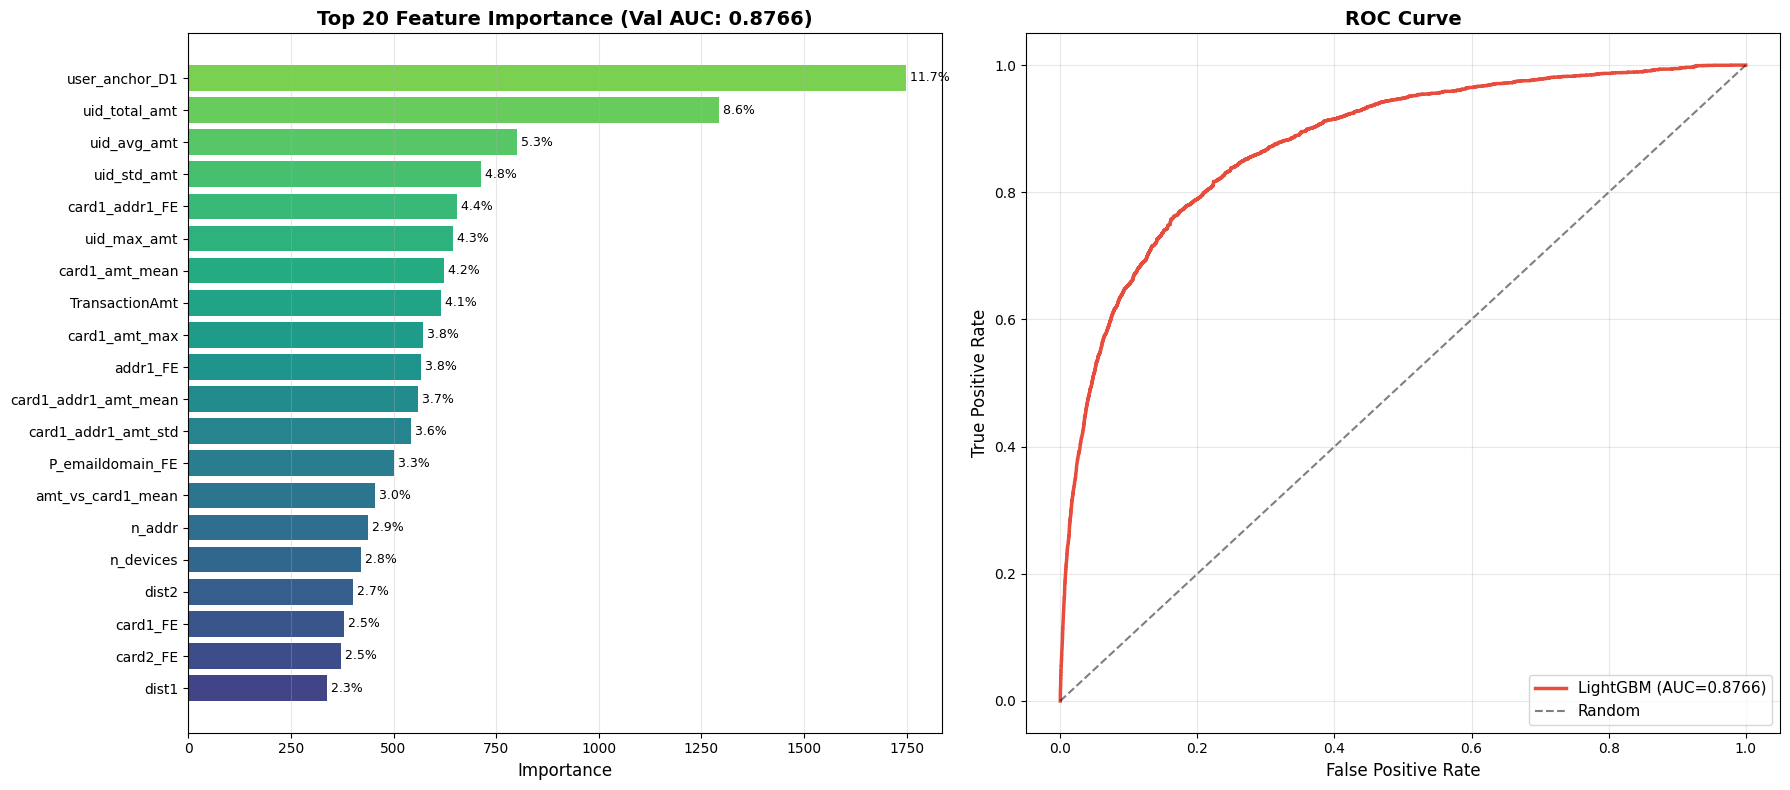

In [20]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Feature Importance (Top 20)
ax1 = axes[0]
top_20_features = feature_importance.head(20)
colors = plt.cm.viridis(np.linspace(0.8, 0.2, len(top_20_features)))
bars = ax1.barh(range(len(top_20_features)), top_20_features['importance'], color=colors)
ax1.set_yticks(range(len(top_20_features)))
ax1.set_yticklabels(top_20_features['feature'])
ax1.invert_yaxis()
ax1.set_xlabel('Importance', fontsize=12)
ax1.set_title(f'Top 20 Feature Importance (Val AUC: {val_auc:.4f})', fontweight='bold', fontsize=14)
ax1.grid(alpha=0.3, axis='x')

for i, (idx, row) in enumerate(top_20_features.iterrows()):
    ax1.text(row['importance'], i, f" {row['importance_pct']:.1f}%", va='center', fontsize=9)

# ROC Curve
ax2 = axes[1]
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
ax2.plot(fpr, tpr, color='#e74c3c', linewidth=2.5, label=f'LightGBM (AUC={val_auc:.4f})')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('True Positive Rate', fontsize=12)
ax2.set_title('ROC Curve', fontweight='bold', fontsize=14)
ax2.legend(loc='lower right', fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# Low importance analysis
very_low_importance = feature_importance[feature_importance['importance_pct'] < 0.1]['feature'].tolist()
zero_importance = feature_importance[feature_importance['importance'] == 0]['feature'].tolist()

print(f"Zero Importance Features ({len(zero_importance)}):")
for feat in zero_importance[:10]:
    print(f"  - {feat}")
if len(zero_importance) > 10:
    print(f"  ... and {len(zero_importance)-10} more")

print(f"\nVery Low Importance (<0.1%) ({len(very_low_importance)}):")
for feat in very_low_importance[:15]:
    imp_pct = feature_importance[feature_importance['feature'] == feat]['importance_pct'].values[0]
    print(f"  - {feat}: {imp_pct:.3f}%")
if len(very_low_importance) > 15:
    print(f"  ... and {len(very_low_importance)-15} more")

print(f"\nRecommendation: Consider dropping {len(zero_importance) + len(very_low_importance)} low-value features")

Zero Importance Features (0):

Very Low Importance (<0.1%) (1):
  - addr2_freq: 0.087%

Recommendation: Consider dropping 1 low-value features


## Veriyi Kaydetme

Feature engineering tamamlandı. Train/Val/Test setlerini kaydediyoruz. Train (%60) model eğitimi için, Val (%20) hyperparameter tuning için, Test (%20) final evaluation için kullanılacak - test setine model geliştirme sürecinde hiç dokunmuyoruz.

In [22]:
# Save processed datasets
import os

data_dir = '../../data/processed'
os.makedirs(data_dir, exist_ok=True)

# Save train/val/test splits
X_train.to_csv(f'{data_dir}/X_train.csv', index=False)
X_val.to_csv(f'{data_dir}/X_val.csv', index=False)
X_test.to_csv(f'{data_dir}/X_test.csv', index=False)
y_train.to_csv(f'{data_dir}/y_train.csv', index=False)
y_val.to_csv(f'{data_dir}/y_val.csv', index=False)
y_test.to_csv(f'{data_dir}/y_test.csv', index=False)

print(f"Saved to {data_dir}/")
print(f"\nDataset sizes:")
print(f"  Train: {X_train.shape[0]:,} x {X_train.shape[1]} features")
print(f"  Val:   {X_val.shape[0]:,} x {X_val.shape[1]} features")
print(f"  Test:  {X_test.shape[0]:,} x {X_test.shape[1]} features")
print(f"\nFraud counts:")
print(f"  Train: {y_train.sum():,} fraud / {len(y_train):,} total")
print(f"  Val:   {y_val.sum():,} fraud / {len(y_val):,} total")
print(f"  Test:  {y_test.sum():,} fraud / {len(y_test):,} total")

Saved to ../../data/processed/

Dataset sizes:
  Train: 354,324 x 36 features
  Val:   118,108 x 36 features
  Test:  118,108 x 36 features

Fraud counts:
  Train: 11,988 fraud / 354,324 total
  Val:   4,611 fraud / 118,108 total
  Test:  4,064 fraud / 118,108 total


## Ne İşe Yaradı, Ne Yaramadı?

Bu projede birçok feature engineering yaklaşımı denedik. Bazıları performansı ciddi şekilde artırdı, bazıları hiç fayda sağlamadı.

**İşe Yarayanlar:**

**Kullanıcı tanımlama (UID)** projenin en güçlü buluşu oldu. card1 ve addr1'i birleştirip pseudo-user ID oluşturduk - bu basit kombinasyon Top 20 feature'ın 5-6 tanesini tek başına sağladı. Aynı kart+adres kombinasyonu muhtemelen aynı kişi, ve bir kişinin normal harcama paterni fraud'dan çok farklı.

**User Anchor D1** tek başına %12 importance aldı. TransactionDT'den D1*86400 çıkarınca kullanıcının ilk işlem zamanını yakalıyoruz. Dikkat: D1 int16 tipinde, 86400 ile çarpmadan önce float64'e çevirmezsen overflow alırsın.

**Tutar analizi** beklenenden iyi çalıştı. İnsanlar yuvarlak (100, 500) veya psikolojik fiyatlar (9.99) tercih ediyor, fraud botları rastgele tutarlar üretiyor. `is_random_amount` güçlü korelasyon gösterdi.

**Card1 aggregasyonları** faydalı çıktı. Her kart için ortalama tutar, kaç farklı adres ve cihazdan kullanılmış - bunlar fraud sinyali taşıyor.

**İşe Yaramayanlar:**

**Transaction velocity features** (günlük işlem sayısı, son işlemden bu yana geçen süre) - UID aggregasyonları zaten bu bilgiyi yakalıyor.

**Email + Address / Device + Address kombinasyonları** - çok fazla missing value (%20+), UID zaten aynı bilgiyi veriyor.

**Card Family (card2-6 kombinasyonu)** - yüzbinlerce unique değer, anlamsız hale geldi.

**_D1_missing, amt_cents_exact, email_match, 3-way features** - düşük importance, modele katkı sağlamadı.

**Önemli Noktalar:**

Redundant binary feature'lardan kaçın (is_round + is_psych + is_random = 1). LightGBM için one-hot encoding gereksiz. Korelasyonu >0.8 olan çiftlerden birini çıkar. Ara kolonları (uid_card1_addr1 gibi) aggregasyon bittikten sonra sil.

## Özet

**Sonuç:** Val AUC ~0.88 | 36 Feature

**Chris Deotte UID Formülü:**
```python
df['day'] = df['TransactionDT'] // 86400
df['anchor_day'] = df['day'] - df['D1'].fillna(0)
df['uid'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str) + '_' + df['anchor_day'].astype(str)
```

**Tutulan Feature'lar (36):**

| Kategori | Feature'lar |
|----------|-------------|
| Base | TransactionAmt, ProductCD, card4, card6, dist1, dist2 |
| UID | user_anchor_D1, uid_avg_amt, uid_std_amt, uid_max_amt, uid_total_amt, amt_vs_uid_month_avg |
| Card1 | card1_amt_mean, card1_amt_max, n_addr, n_devices, card1_addr1_amt_mean, card1_addr1_amt_std |
| FE | card1_FE, addr1_FE, card1_addr1_FE, card2_FE, card3_FE, card5_FE, P_emaildomain_FE, R_emaildomain_FE |
| Amount | is_random_amount, amt_vs_card1_mean |
| Frequency | card1_freq → R_emaildomain_freq (8 adet) |

**Çıkarılan Feature'lar:**

*Yüksek korelasyon (>0.8):* amt_dollars, uid_txn_count, uid_month_avg_amt, uid_month_txn_count, amt_vs_card1_addr1_mean, uid_week_txn_count, card1_amt_std, uid_min_amt, uid_week_avg_amt ve ratio karşılıkları

*Düşük importance:* _D1_missing, amt_cents_exact, email_match, card1_addr1_P_emaildomain_FE, TransactionAmt_card1_addr1_P_emaildomain_mean/std

**Top 5 Feature Importance:**
1. user_anchor_D1 (10.76%)
2. uid_total_amt (7.65%)
3. TransactionAmt (5.56%)
4. uid_avg_amt (4.74%)
5. card1_amt_mean (4.68%)